In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme()

gen = pd.read_csv("../data/cleaned/Plant_1_Generation_Cleaned.csv")
weather = pd.read_csv("../data/cleaned/Plant_1_Weather_Cleaned.csv")

gen["DATE_TIME"] = pd.to_datetime(gen["DATE_TIME"])
weather["DATE_TIME"] = pd.to_datetime(weather["DATE_TIME"])


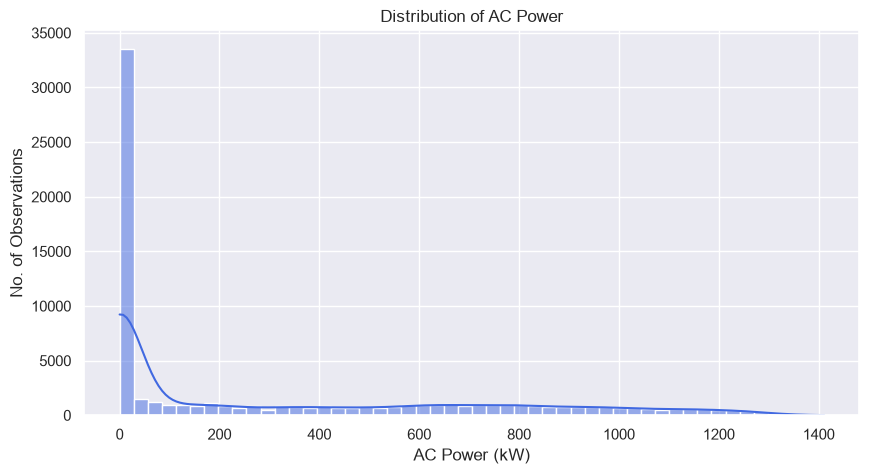

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=gen,
    x="AC_POWER",
    bins=50,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of AC Power")
plt.xlabel("AC Power (kW)")
plt.ylabel("No. of Observations")

plt.show()

# 1. Distribution of AC Power

## Objective

The objective of this analysis is to understand the distribution of AC power generated by the solar plant. Since AC power is the target variable for prediction, studying its distribution helps identify the overall behavior of power generation and detect any skewness or concentration of values.

## Observation

- The distribution of AC power is positively skewed.
- A large number of observations have AC power equal to zero.
- High AC power values occur less frequently than lower values.

## Business Insight

The high frequency of zero AC power values indicates periods when the solar plant is not generating electricity, primarily during nighttime. This suggests that temporal features such as the hour of the day and weather-related variables like irradiation will be important predictors for forecasting solar power generation.

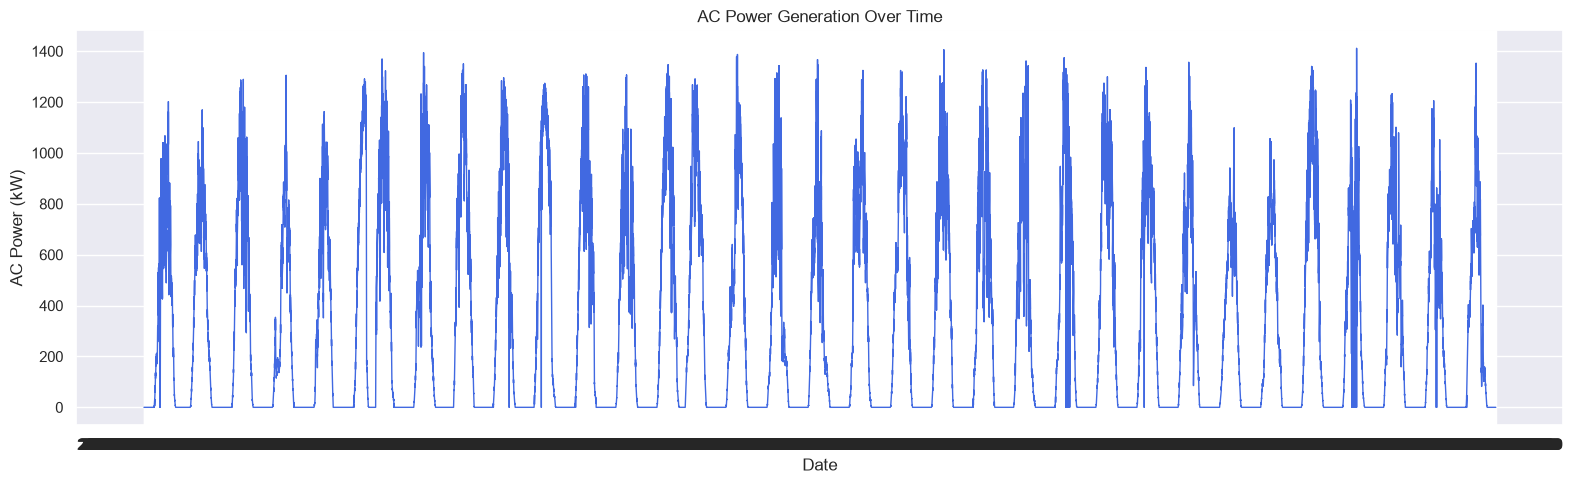

In [5]:
plt.figure(figsize=(16,5))

plt.plot(
    gen["DATE_TIME"],
    gen["AC_POWER"],
    color="royalblue",
    linewidth=1
)

plt.title("AC Power Generation Over Time")
plt.xlabel("Date")
plt.ylabel("AC Power (kW)")

plt.tight_layout()
plt.show()

# 2. AC Power Generation Over Time

## Objective

The objective of this analysis is to examine how AC power generation changes over time. This helps identify daily generation patterns, periods of peak production, and any unusual fluctuations or interruptions in power output.

## Observation

- AC power follows a clear daily cycle, increasing after sunrise and decreasing towards sunset.
- Power generation drops to nearly zero during nighttime.
- Peak power generation occurs during the middle of the day when sunlight is strongest.
- The overall trend appears consistent across different days.

## Business Insight

The observed daily pattern confirms that solar power generation is highly dependent on the availability of sunlight. This indicates that features such as time of day and solar irradiation are likely to have a significant influence on power generation and should be included in the prediction model.

C:\Users\HP\AppData\Local\Temp\ipykernel_13824\2741670832.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


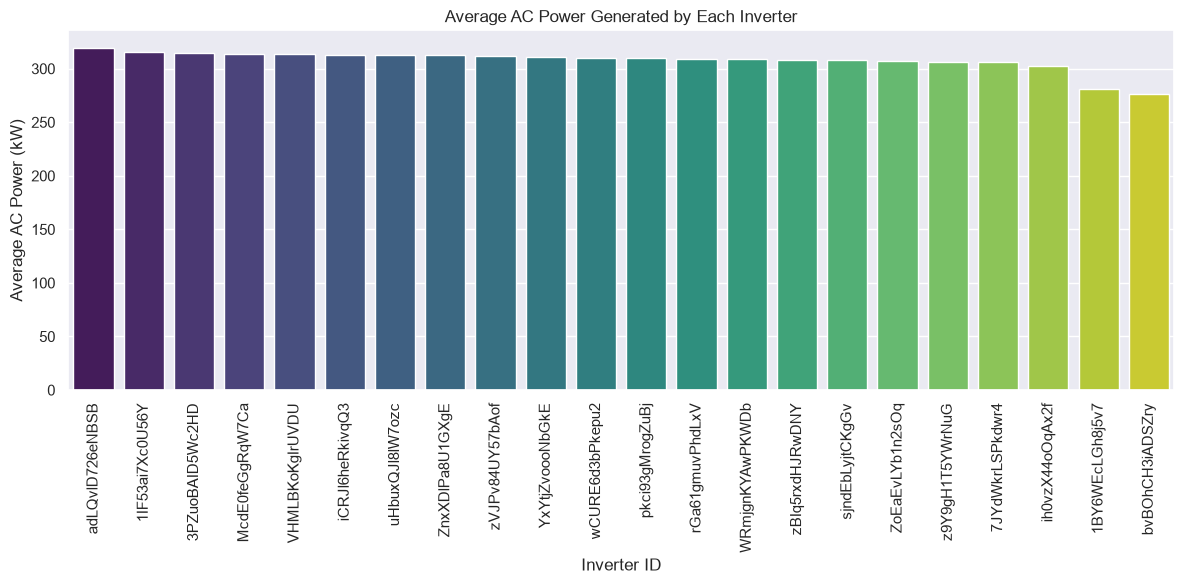

In [6]:
plt.figure(figsize=(12,6))

avg_power = (
    gen.groupby("SOURCE_KEY")["AC_POWER"]
       .mean()
       .sort_values(ascending=False)
)

sns.barplot(
    x=avg_power.index,
    y=avg_power.values,
    palette="viridis"
)

plt.title("Average AC Power Generated by Each Inverter")
plt.xlabel("Inverter ID")
plt.ylabel("Average AC Power (kW)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# 3. Average AC Power by Inverter

## Objective

The objective of this analysis is to compare the average AC power generated by each inverter in the solar plant. This helps identify high-performing and low-performing inverters and evaluate whether all inverters are operating at similar efficiency levels.

## Observation

- The average AC power generated varies across different inverters.
- Some inverters consistently generate higher average power than others.
- A few inverters produce noticeably lower power compared to the rest.

## Business Insight

Comparing inverter performance helps identify potential underperforming equipment that may require inspection or maintenance. Such analysis enables plant operators to improve overall energy production by detecting inefficient inverters at an early stage.

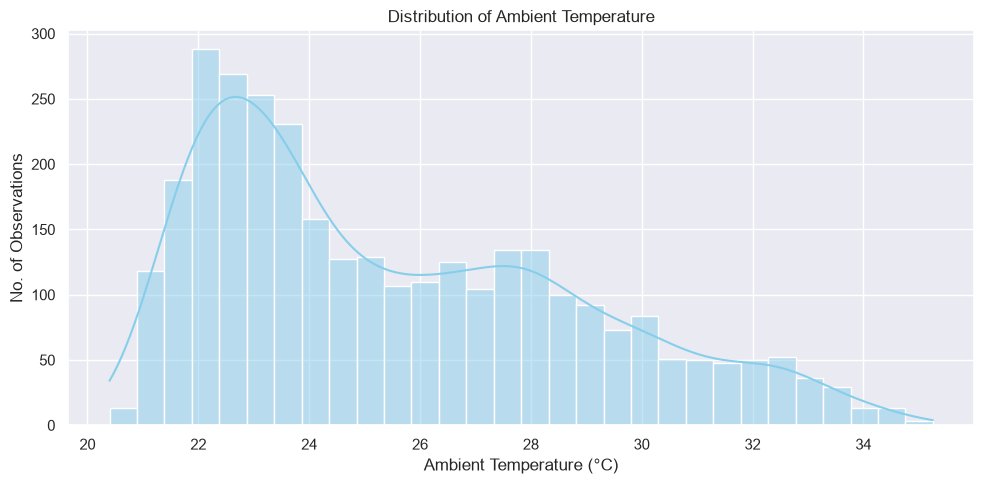

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=weather,
    x="AMBIENT_TEMPERATURE",
    bins=30,
    kde=True,
    color="skyblue"
)

plt.title("Distribution of Ambient Temperature")
plt.xlabel("Ambient Temperature (°C)")
plt.ylabel("No. of Observations")

plt.tight_layout()
plt.show()

# 4. Distribution of Ambient Temperature

## Objective

The objective of this analysis is to understand the distribution of ambient temperature recorded at the solar plant. Analyzing ambient temperature helps identify the typical operating conditions under which the solar panels generate electricity.

## Observation

- Ambient temperature values are concentrated within a moderate range.
- Extremely low or extremely high temperatures occur very rarely.
- The distribution indicates stable weather conditions during the data collection period.

## Business Insight

Ambient temperature influences the operating conditions of solar panels. Although it does not directly generate electricity, it affects panel efficiency and is an important feature for understanding and predicting solar power generation.

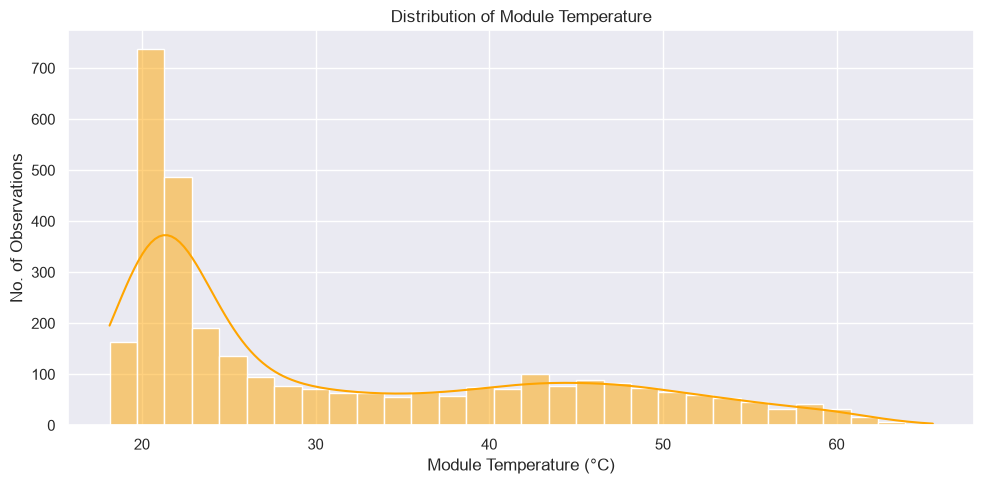

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=weather,
    x="MODULE_TEMPERATURE",
    bins=30,
    kde=True,
    color="orange"
)

plt.title("Distribution of Module Temperature")
plt.xlabel("Module Temperature (°C)")
plt.ylabel("No. of Observations")

plt.tight_layout()
plt.show()

# 5. Distribution of Module Temperature

## Objective

The objective of this analysis is to examine the distribution of the solar panel module temperature during the observation period. Module temperature is an important operational parameter because it directly influences the efficiency and performance of photovoltaic panels.

## Observation

- Module temperature is generally higher than the ambient temperature.
- Most observations fall within a moderate operating temperature range.
- Extremely high module temperatures are observed less frequently.

## Business Insight

Solar panels absorb sunlight and therefore become hotter than the surrounding air. Higher module temperatures can reduce the efficiency of solar panels, making module temperature an important feature for analyzing plant performance and predicting power generation.

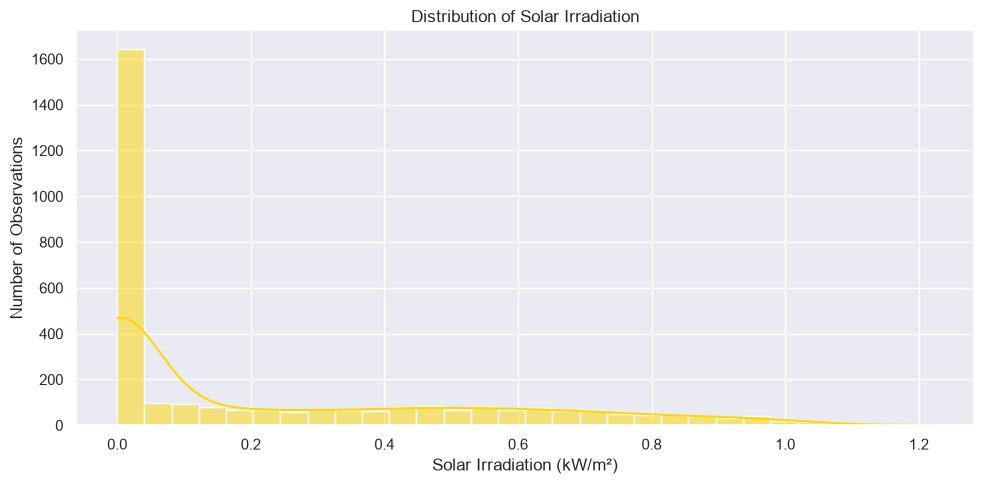

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=weather,
    x="IRRADIATION",
    bins=30,
    kde=True,
    color="gold"
)

plt.title("Distribution of Solar Irradiation")
plt.xlabel("Solar Irradiation (kW/m²)")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

# 6. Distribution of Solar Irradiation

## Objective

The objective of this analysis is to examine the distribution of solar irradiation received by the solar plant. Solar irradiation represents the amount of sunlight available for electricity generation and is expected to be one of the most influential factors affecting power output.

## Observation

- A large number of observations have irradiation values close to zero.
- Higher irradiation values occur less frequently and are concentrated during daylight hours.
- The distribution is positively skewed.

## Business Insight

The high number of near-zero irradiation values corresponds to nighttime or periods with very low sunlight. Since solar panels require sunlight to generate electricity, solar irradiation is expected to have a strong positive relationship with AC power generation and will likely be one of the most important features in the prediction model.

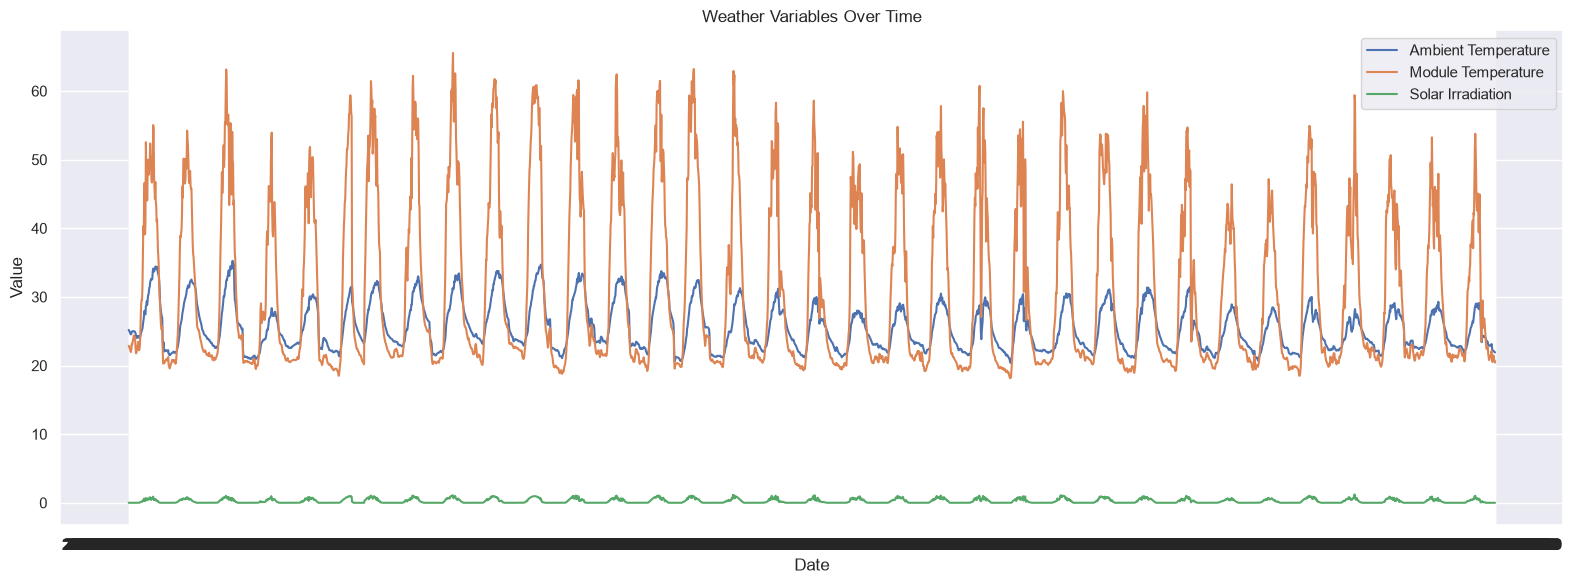

In [12]:
plt.figure(figsize=(16,6))

plt.plot(
    weather["DATE_TIME"],
    weather["AMBIENT_TEMPERATURE"],
    label="Ambient Temperature",
    linewidth=1.5
)

plt.plot(
    weather["DATE_TIME"],
    weather["MODULE_TEMPERATURE"],
    label="Module Temperature",
    linewidth=1.5
)

plt.plot(
    weather["DATE_TIME"],
    weather["IRRADIATION"],
    label="Solar Irradiation",
    linewidth=1.5
)

plt.title("Weather Variables Over Time")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()

plt.tight_layout()
plt.show()

# 7. Weather Trends Over Time

## Objective

The objective of this analysis is to study how ambient temperature, module temperature, and solar irradiation vary over time. Understanding these trends helps identify daily weather patterns and provides insights into the environmental conditions affecting solar power generation.

## Observation

- Ambient and module temperatures increase during the daytime and decrease during the night.
- Module temperature remains higher than ambient temperature for most of the observation period.
- Solar irradiation is close to zero during nighttime and reaches its highest values during the middle of the day.
- The weather variables exhibit a consistent daily cycle throughout the dataset.

## Business Insight

The daily variation in weather conditions directly influences solar power generation. The increase in irradiation and temperature during daylight hours explains the rise in electricity production, while the absence of sunlight at night results in zero power generation.

In [20]:
merged = pd.merge(
    gen,
    weather,
    on=["DATE_TIME", "PLANT_ID"],
    how="inner"
)

merged.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


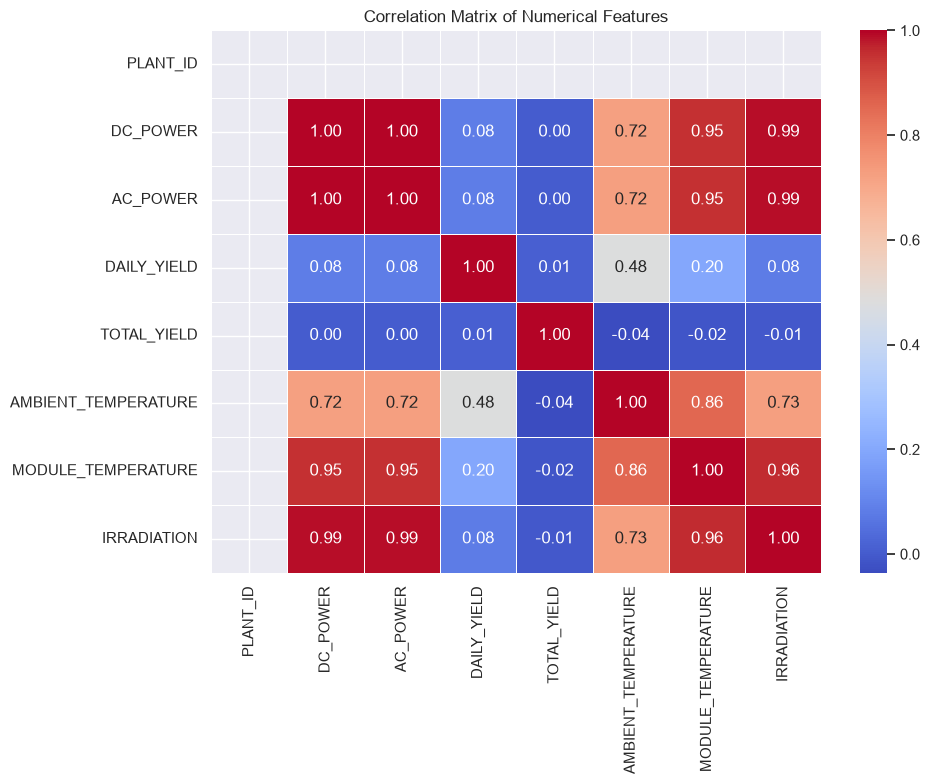

In [14]:
plt.figure(figsize=(10,8))

corr = merged.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

# 8. Correlation Analysis

## Objective

The objective of this analysis is to examine the relationships between the numerical variables in the dataset. The correlation matrix helps identify which features are strongly associated with AC power generation and assists in selecting relevant variables for the machine learning model.

## Observation

- AC power has a strong positive correlation with DC power and solar irradiation.
- Module temperature also shows a positive correlation with AC power.
- Ambient temperature has a relatively weaker correlation with AC power.
- Daily Yield and Total Yield exhibit different correlation strengths because they represent cumulative energy production.

## Business Insight

The correlation analysis indicates that solar irradiation and DC power are among the most influential variables affecting AC power generation. These features are expected to play an important role in building an accurate prediction model, while features with weak correlations may contribute less to the model's performance.

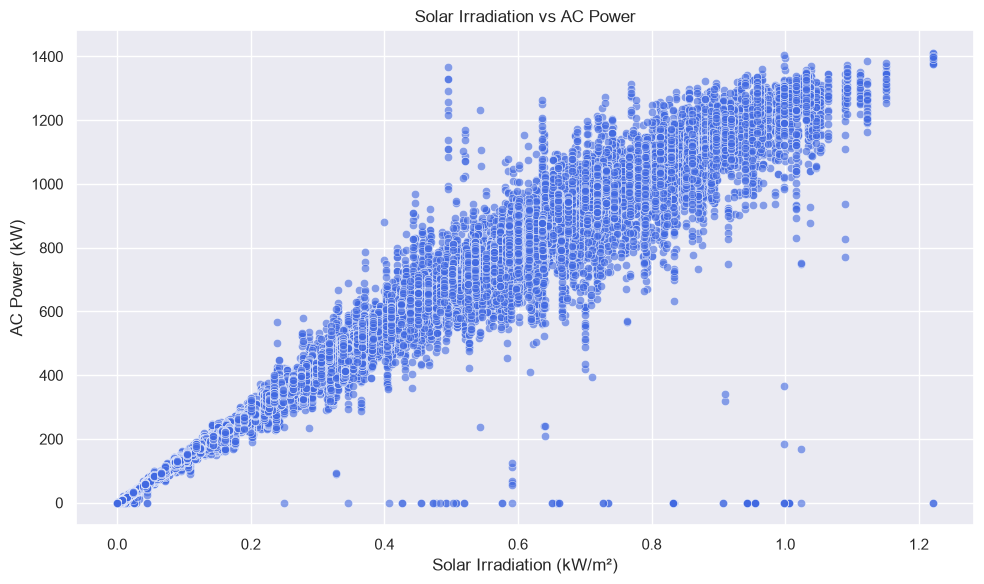

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged,
    x="IRRADIATION",
    y="AC_POWER",
    alpha=0.6,
    color="royalblue"
)

plt.title("Solar Irradiation vs AC Power")
plt.xlabel("Solar Irradiation (kW/m²)")
plt.ylabel("AC Power (kW)")

plt.tight_layout()
plt.show()

# 9. Relationship Between Solar Irradiation and AC Power

## Objective

The objective of this analysis is to examine the relationship between solar irradiation and AC power generation. Since solar panels convert sunlight into electricity, understanding this relationship helps determine how strongly sunlight influences the plant's power output.

## Observation

- AC power generally increases as solar irradiation increases.
- A strong positive relationship exists between irradiation and AC power.
- When irradiation is close to zero, AC power is also nearly zero.
- Some variation is observed at higher irradiation levels due to factors such as panel temperature, inverter efficiency, and environmental conditions.

## Business Insight

Solar irradiation is the primary source of energy for photovoltaic panels. The strong positive relationship confirms that irradiation is one of the most important features for predicting AC power generation. This variable should therefore be included in the machine learning model as a key predictor.

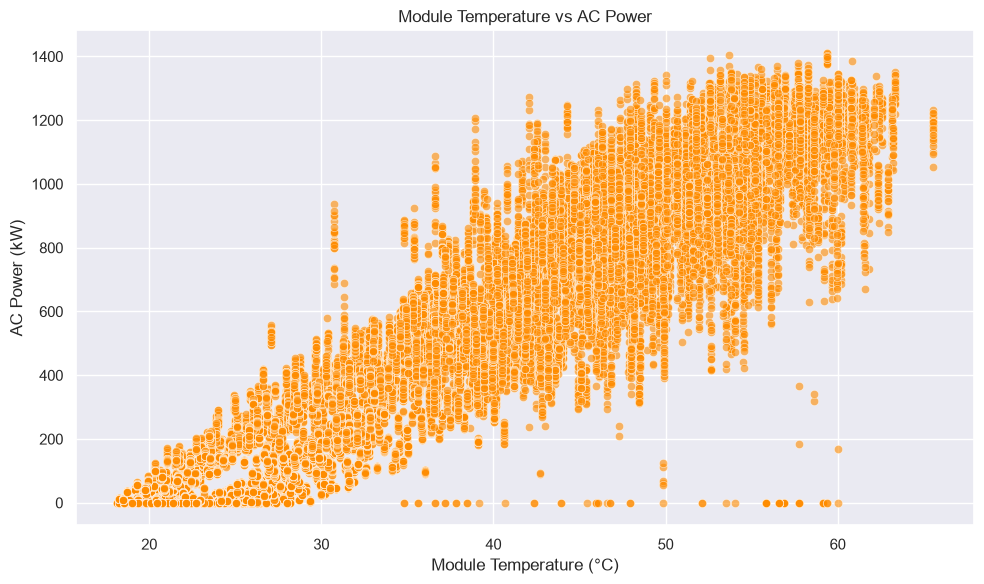

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged,
    x="MODULE_TEMPERATURE",
    y="AC_POWER",
    alpha=0.6,
    color="darkorange"
)

plt.title("Module Temperature vs AC Power")
plt.xlabel("Module Temperature (°C)")
plt.ylabel("AC Power (kW)")

plt.tight_layout()
plt.show()

# 10. Relationship Between Module Temperature and AC Power

## Objective

The objective of this analysis is to examine how the temperature of the solar panel modules influences AC power generation. Since photovoltaic panels heat up during operation, understanding this relationship helps evaluate the impact of panel temperature on plant performance.

## Observation

- AC power generally increases with module temperature up to a certain range.
- The relationship is positive but not perfectly linear.
- The spread of data points increases at higher temperatures, indicating that factors other than temperature also influence power generation.

## Business Insight

Module temperature is an important operational parameter because it affects the efficiency of photovoltaic panels. While higher temperatures are associated with increased sunlight and power generation, excessive panel heating can reduce efficiency. Therefore, module temperature should be considered alongside solar irradiation when developing the prediction model.

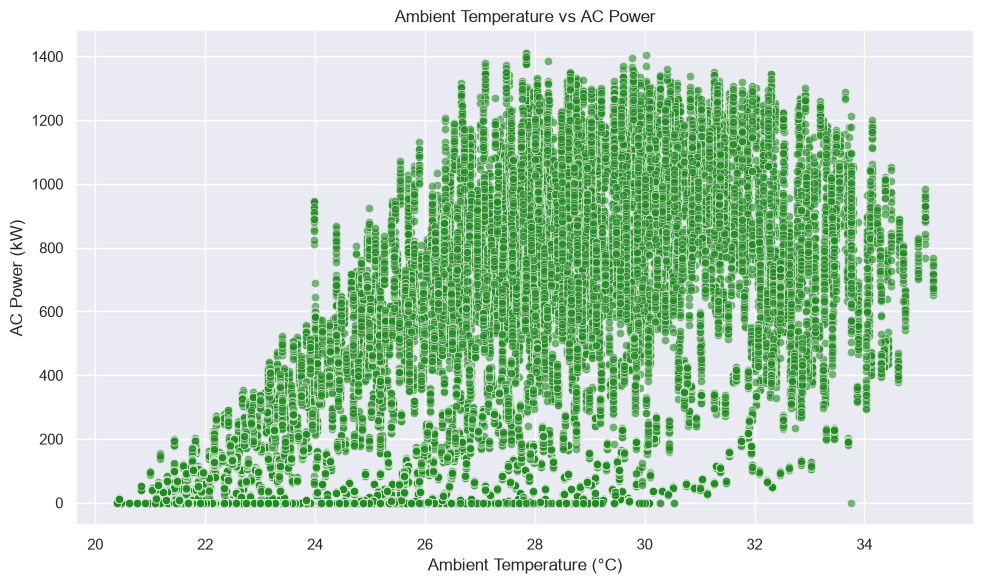

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged,
    x="AMBIENT_TEMPERATURE",
    y="AC_POWER",
    alpha=0.6,
    color="forestgreen"
)

plt.title("Ambient Temperature vs AC Power")
plt.xlabel("Ambient Temperature (°C)")
plt.ylabel("AC Power (kW)")

plt.tight_layout()
plt.show()

# 11. Relationship Between Ambient Temperature and AC Power

## Objective

The objective of this analysis is to investigate the relationship between ambient temperature and AC power generation. Unlike module temperature, ambient temperature represents the surrounding environmental conditions and helps determine whether external weather conditions influence solar power production.

## Observation

- AC power generally increases as ambient temperature increases during daylight hours.
- The relationship is weaker than that observed between solar irradiation and AC power.
- A noticeable spread in the data indicates that ambient temperature alone does not explain the variation in power generation.

## Business Insight

Ambient temperature has an indirect influence on solar power generation. Although warmer weather often coincides with sunny conditions, ambient temperature alone is not a strong predictor of AC power. Solar irradiation remains the dominant factor, while ambient temperature provides additional contextual information for the prediction model.

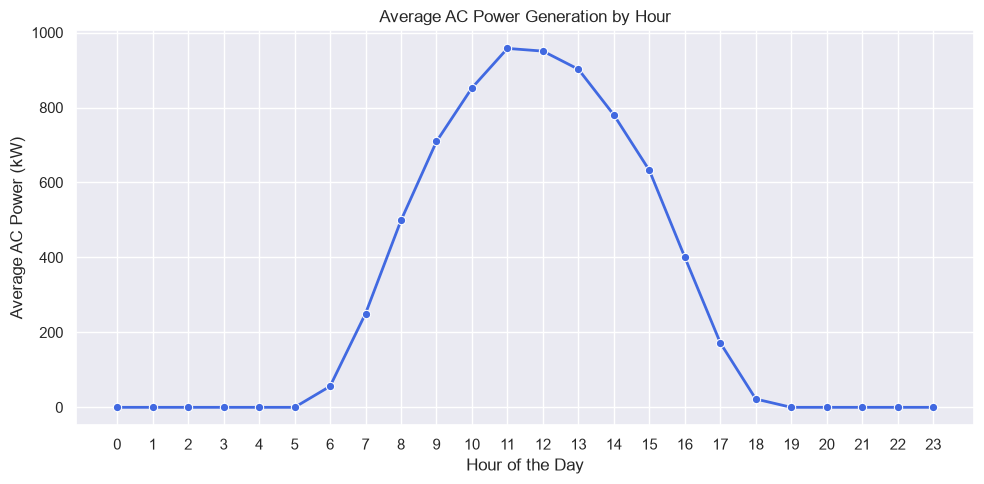

In [21]:
merged["HOUR"] = merged["DATE_TIME"].dt.hour

hourly_power = (
    merged.groupby("HOUR")["AC_POWER"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=hourly_power,
    x="HOUR",
    y="AC_POWER",
    marker="o",
    linewidth=2,
    color="royalblue"
)

plt.title("Average AC Power Generation by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Average AC Power (kW)")
plt.xticks(range(0,24))

plt.grid(True)

plt.tight_layout()
plt.show()

# 12. Average AC Power Generation by Hour

## Objective

The objective of this analysis is to identify the average AC power generated during each hour of the day. Understanding hourly generation patterns helps determine the peak production period and provides insights into the operational behavior of the solar power plant.

## Observation

- Power generation begins after sunrise and gradually increases during the morning.
- Average AC power reaches its highest level around midday.
- After the peak period, power generation gradually decreases as sunlight intensity reduces.
- During nighttime hours, AC power remains close to zero.

## Business Insight

The hourly generation pattern reflects the daily availability of solar radiation. Identifying peak generation hours helps optimize energy management, maintenance scheduling, and grid operations. Time-related features such as the hour of the day are expected to be valuable predictors in the machine learning model.

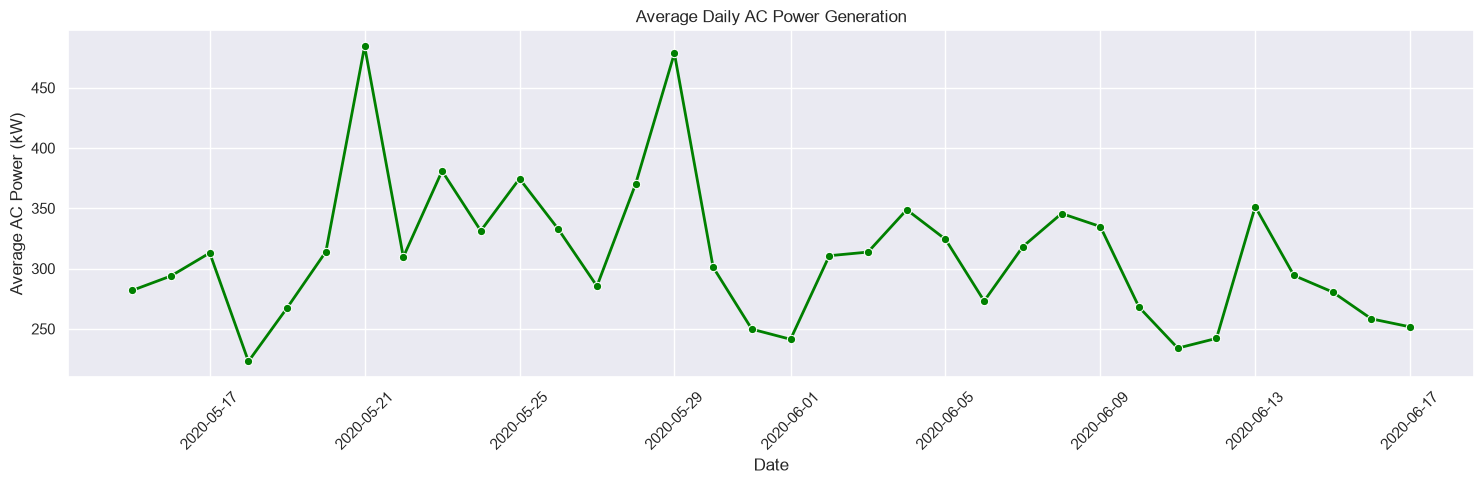

In [22]:
merged["DATE"] = merged["DATE_TIME"].dt.date

daily_power = (
    merged.groupby("DATE")["AC_POWER"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(15,5))

sns.lineplot(
    data=daily_power,
    x="DATE",
    y="AC_POWER",
    marker="o",
    linewidth=2,
    color="green"
)

plt.title("Average Daily AC Power Generation")
plt.xlabel("Date")
plt.ylabel("Average AC Power (kW)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 13. Average Daily AC Power Generation

## Objective

The objective of this analysis is to examine the average AC power generated each day during the observation period. Studying daily generation patterns helps identify variations in plant performance and determine whether electricity production remains consistent over time.

## Observation

- Daily average AC power remains relatively consistent throughout the observation period.
- Some days exhibit slightly higher or lower power generation than others.
- No significant long-term increasing or decreasing trend is observed.

## Business Insight

Daily power generation can vary due to changes in weather conditions such as cloud cover, solar irradiation, and temperature. Monitoring daily generation helps plant operators detect abnormal performance and evaluate overall plant stability.

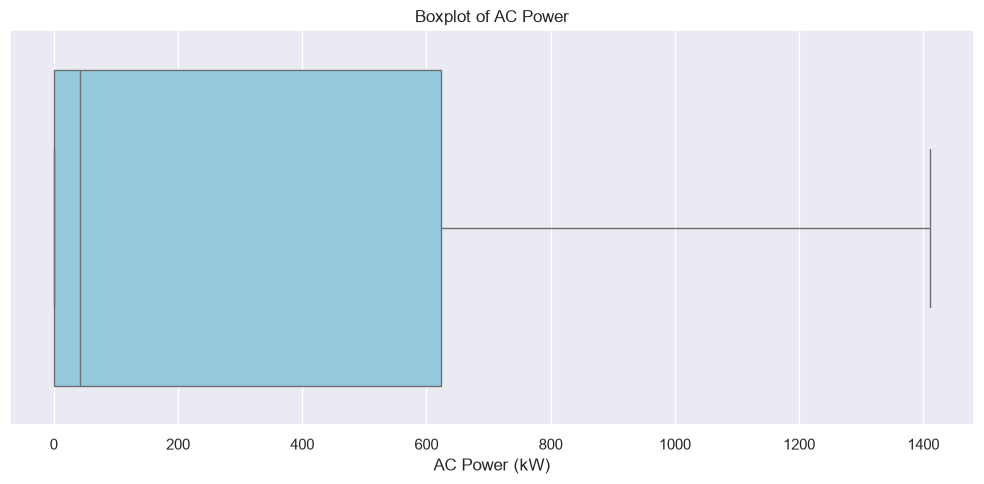

In [23]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=merged["AC_POWER"],
    color="skyblue"
)

plt.title("Boxplot of AC Power")
plt.xlabel("AC Power (kW)")

plt.tight_layout()
plt.show()

# 14. Outlier Analysis of AC Power

## Objective

The objective of this analysis is to identify the presence of outliers in AC power generation. A boxplot provides a summary of the data distribution and highlights observations that differ significantly from the majority of the data.

## Observation

- The distribution of AC power contains several values outside the whiskers of the boxplot.
- Most observations lie within a relatively compact range, while a few observations represent unusually high power generation.
- These outliers are likely to correspond to periods of peak solar irradiation rather than measurement errors.

## Business Insight

In a solar power plant, unusually high power values are often genuine observations recorded during periods of maximum sunlight. Therefore, these outliers should be carefully investigated before removal, as they may represent important operational behavior rather than incorrect data.

---
<br>
<br>
<br>

---


# 15. Key Insights from Exploratory Data Analysis

## Summary

The exploratory data analysis provided several important insights into the operational behavior of the solar power plant.

### Key Findings

- AC power generation follows a clear daily cycle, with almost no generation during nighttime.
- Solar irradiation shows the strongest positive relationship with AC power generation.
- Module temperature is generally higher than ambient temperature because solar panels absorb heat while generating electricity.
- The performance of individual inverters varies, indicating differences in operational efficiency.
- Peak power generation occurs during the middle of the day when solar irradiation is highest.
- Daily power generation remains relatively stable, with minor variations caused by changing weather conditions.
- The dataset contains no missing values or duplicate records, making it suitable for further analysis and machine learning.

## Conclusion

The analysis indicates that solar irradiation, module temperature, ambient temperature, and time-related features are important variables for predicting AC power generation. These findings will guide the feature engineering and model development stages of the project.